# CSE 4820 Final Project
#### Using Ridge Regression, Support Vector Machines, and Neural Networks


In [ ]:
# !pip install optuna
#!pip install tensorflow
# !pip install scikeras


     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     --------------------------------- ------ 6.6/7.8 MB 32.3 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 29.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [10 lines of output]
      ERROR: Ignored the following yanked versions: 2.4.0
      ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python <3.13,>=3.9; 1.26.1 Requires-Python <3.13,>=3.9
      ERROR: Could not find a version that satisfies the requirement numpy==2.0.0rc1 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16

In [43]:
import numpy as np
import pandas as pd
import scipy as sp
import sklearn as sk
import matplotlib.pyplot as plt
from scipy.stats  import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import statsmodels.api as sm
from statsmodels.tools.tools import pinv_extended
from sklearn.model_selection import KFold as kf
from sklearn.preprocessing import StandardScaler
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [3]:
data = pd.read_csv("CarPrice_Assignment.csv")
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
# removing irrelevant/identifying predictors
data = data.drop(columns=["car_ID", "symboling", "CarName"])

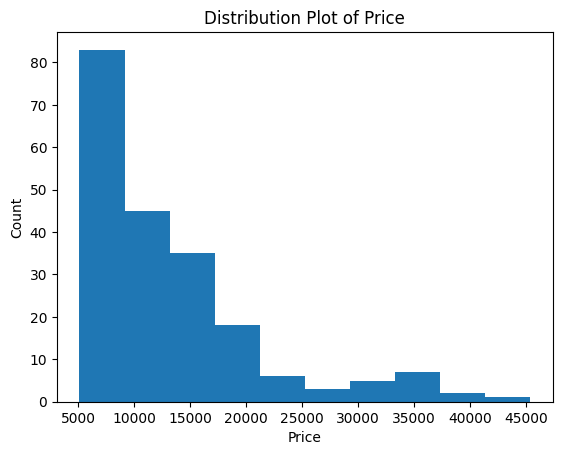

In [5]:
# split data
X = data.drop(columns={"price"})
y = data["price"]

plt.hist(y)
plt.title("Distribution Plot of Price")
plt.xlabel("Price")
plt.ylabel("Count")

y = np.log(y)  # log(1 + price) to handle any zeros

Text(0, 0.5, 'Count')

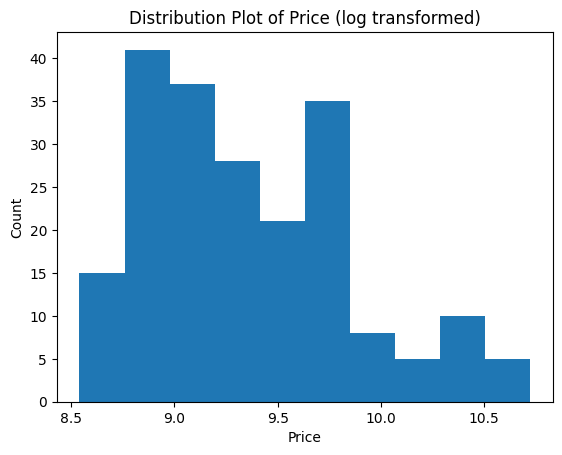

In [6]:
plt.hist(y)
plt.title("Distribution Plot of Price (log transformed)")
plt.xlabel("Price")
plt.ylabel("Count")

In [7]:
str_var = []
for i in X.columns:
    class_type = type(X[i][0])
    if str(class_type) == "<class 'str'>":
        str_var.append(i)

for x in str_var:
    print(x, X[x].unique())

num_var = list(set(list(X.columns)) - set(str_var))

fueltype ['gas' 'diesel']
aspiration ['std' 'turbo']
doornumber ['two' 'four']
carbody ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
drivewheel ['rwd' 'fwd' '4wd']
enginelocation ['front' 'rear']
enginetype ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
cylindernumber ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
fuelsystem ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


In [8]:
from sklearn.preprocessing import OneHotEncoder

# One hot encode categorical variables
cat_data = {"fueltype": list(X["fueltype"]),
            "aspiration": list(X["aspiration"]),
            "doornumber": list(X["doornumber"]),
            "carbody": list(X["carbody"]),
            "drivewheel": list(X["drivewheel"]),
            "enginelocation": list(X["enginelocation"]),
            "enginetype": list(X["enginetype"]),
            "cylindernumber": list(X["cylindernumber"]),
            "fuelsystem": list(X["fuelsystem"])}

df = pd.DataFrame(cat_data)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
df_encoded

,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,doornumber_four,doornumber_two,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,...,cylindernumber_twelve,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
203,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [9]:
# new dataframe with one hot encoded var
X = pd.concat([X[num_var], df_encoded], axis=1)
len(X.columns)

51

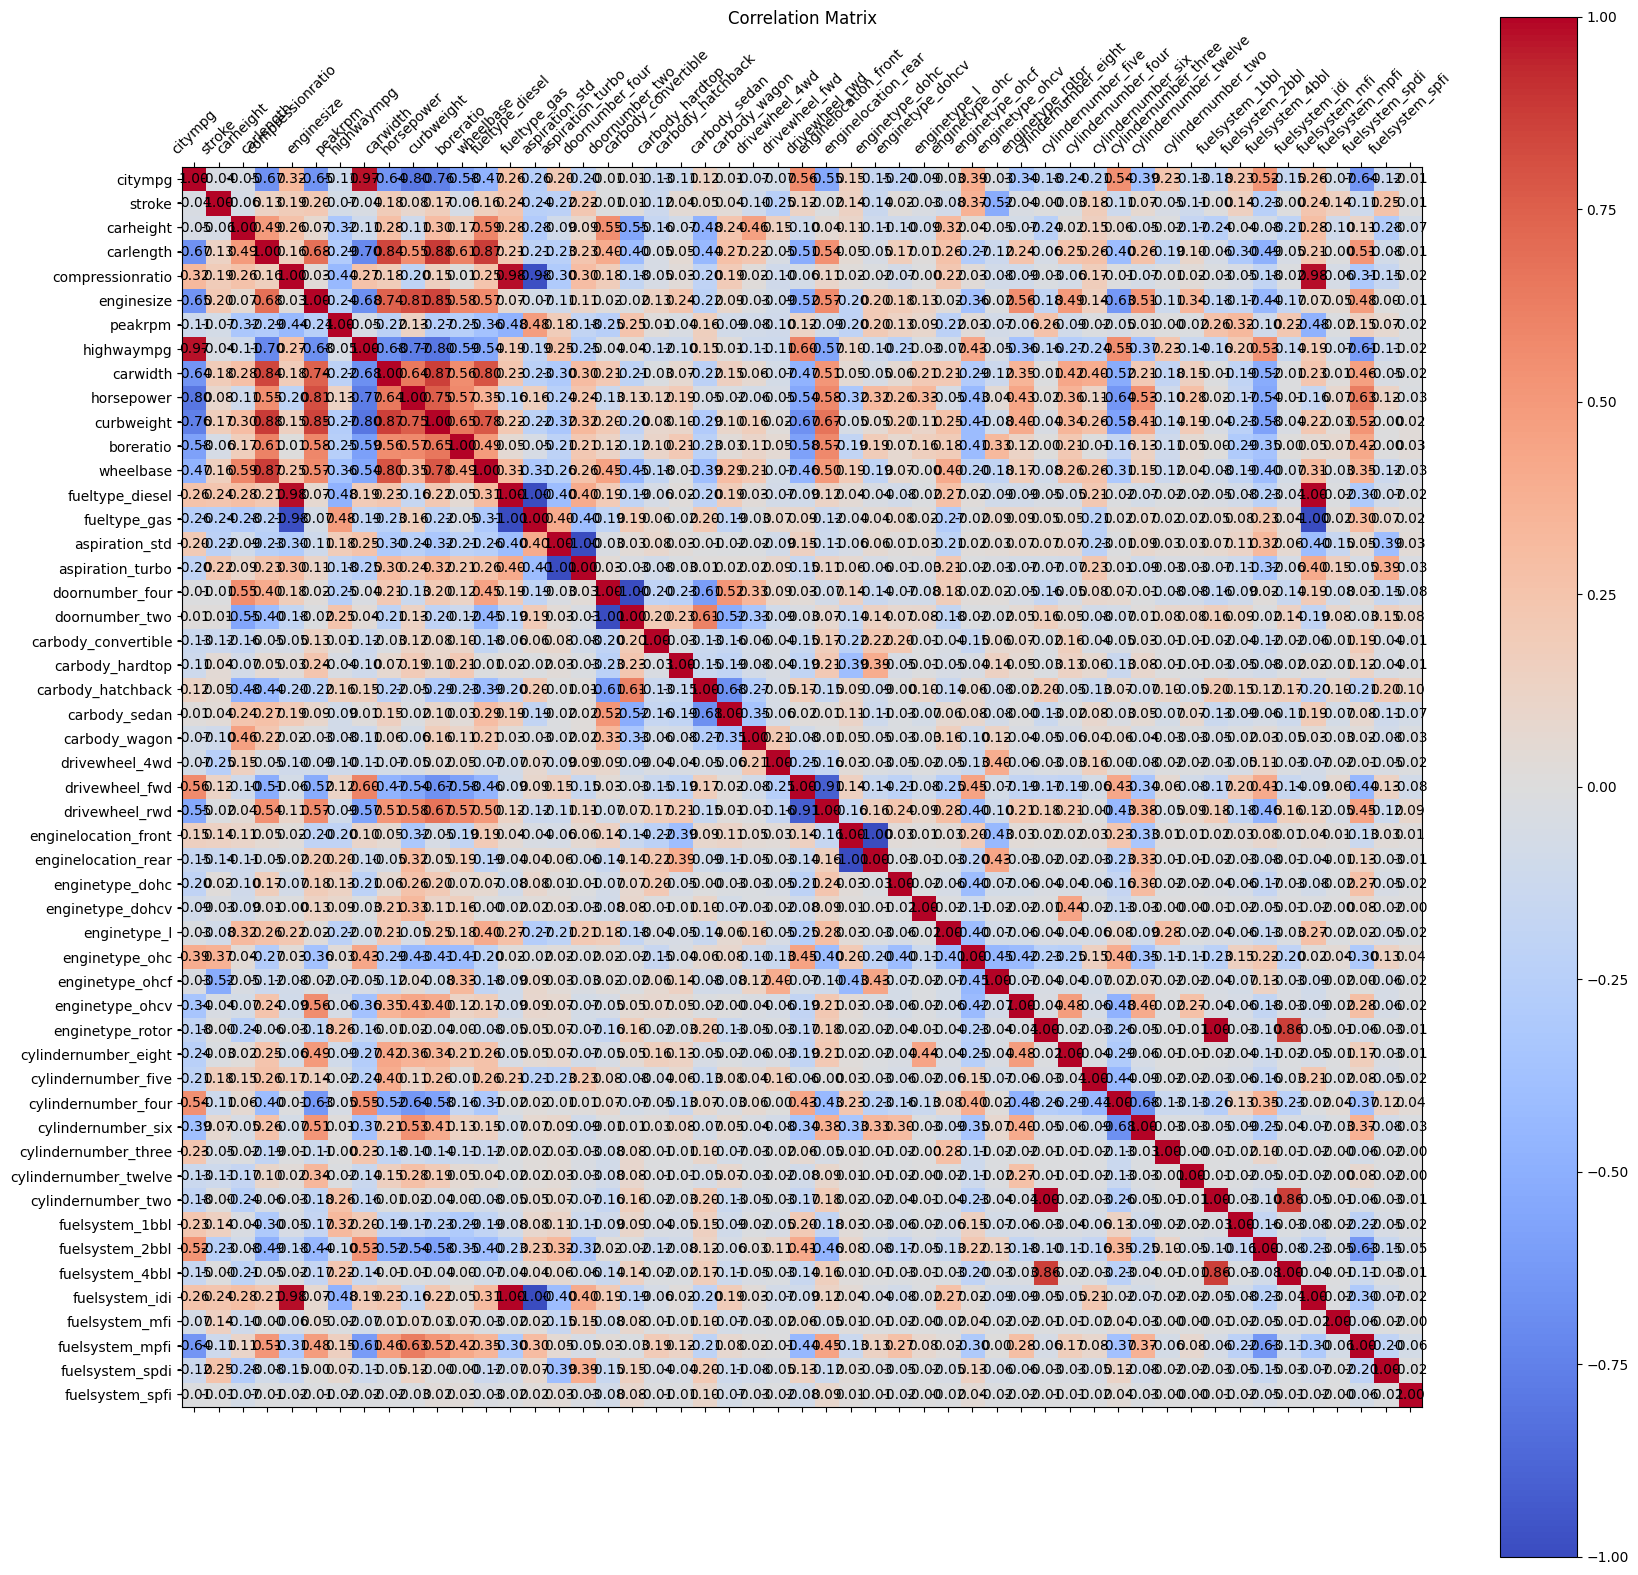

In [10]:
corr_matrix = X.corr()
fig, ax = plt.subplots(figsize=(20, 20))
cax = ax.matshow(corr_matrix, cmap='coolwarm')

plt.colorbar(cax)

# Set axis labels
ax.set_xticks(range(len(X.columns)))
ax.set_yticks(range(len(X.columns)))

ax.set_xticklabels(X.columns, rotation=45)
ax.set_yticklabels(X.columns)

# Add numerical values
for (i, j), val in np.ndenumerate(corr_matrix):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.show()

In [11]:
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_corr = corr_matrix.where(upper_triangle)

to_drop = set()
for col in upper_corr.columns:
    for row in upper_corr.index:
        if upper_corr.loc[row, col] > 0.8 and col not in to_drop:
            to_drop.add(col)

X = X.drop(columns=list(to_drop))

In [12]:
print(to_drop)

{'fuelsystem_4bbl', 'fueltype_gas', 'drivewheel_rwd', 'fueltype_diesel', 'aspiration_turbo', 'carwidth', 'highwaympg', 'curbweight', 'horsepower', 'wheelbase', 'doornumber_two', 'cylindernumber_two', 'fuelsystem_idi', 'enginelocation_rear'}


In [13]:
X.columns

Index(['citympg', 'stroke', 'carheight', 'carlength', 'compressionratio',
       'enginesize', 'peakrpm', 'boreratio', 'aspiration_std',
       'doornumber_four', 'carbody_convertible', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_4wd',
       'drivewheel_fwd', 'enginelocation_front', 'enginetype_dohc',
       'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf',
       'enginetype_ohcv', 'enginetype_rotor', 'cylindernumber_eight',
       'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_six',
       'cylindernumber_three', 'cylindernumber_twelve', 'fuelsystem_1bbl',
       'fuelsystem_2bbl', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi'],
      dtype='object')

In [14]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X,
                                                    y,
                                                    random_state=314,
                                                    test_size=0.20,
                                                    shuffle=True) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression

Best alpha: 4.641588833612782


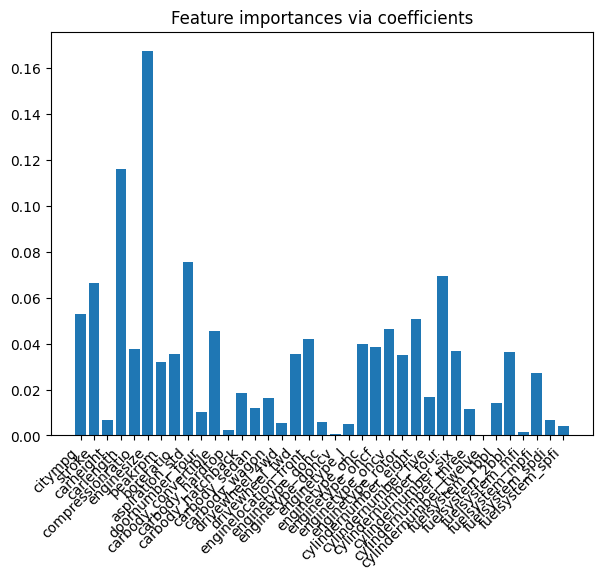

RMSE: 2822.67
MAE:  1835.73
R²:   0.9088


In [15]:
from sklearn.linear_model import RidgeCV
ridgeCV_model = sk.linear_model.RidgeCV(alphas=np.logspace(-6, 6, num=100))
ridgeCV_model.fit(X_train_scaled, y_train)

# Predict car price
y_pred_ridgeCV = np.exp(ridgeCV_model.predict(X_test_scaled))
y_test_actual = np.exp(y_test)

ridgeCV_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_ridgeCV))
ridgeCV_mae = mean_absolute_error(y_test_actual, y_pred_ridgeCV)
ridgeCV_r2 = r2_score(y_test_actual, y_pred_ridgeCV)

print(f"Best alpha: {ridgeCV_model.alpha_}")
importance_ridge = np.abs(ridgeCV_model.coef_)

colList = X_train.columns
feature_names = np.array(colList)

plt.bar(height=importance_ridge, x=feature_names)
plt.title("Feature importances via coefficients")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

print(f"RMSE: {ridgeCV_rmse:.2f}")
print(f"MAE:  {ridgeCV_mae:.2f}")
print(f"R²:   {ridgeCV_r2:.4f}")

# Support Vector Machine

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

param_grid = {'C': [1, 10, 100, 1000], 'epsilon': [0.01, 0.1, 1]}
grid = GridSearchCV(sk.svm.SVR(kernel='linear'), param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

{'C': 1, 'epsilon': 0.01}


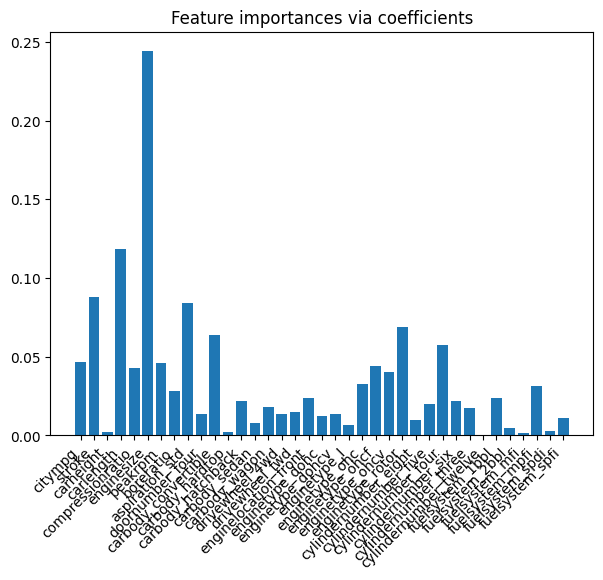

RMSE: 4745.44
MAE:  2449.08
R²:   0.7422


In [23]:
svr_linear = sk.svm.SVR(kernel='linear', C=grid.best_params_["C"], epsilon=grid.best_params_["epsilon"])
svr_linear.fit(X_train_scaled, y_train)

y_pred_SVM = np.exp(grid.best_estimator_.predict(X_test_scaled))
SVM_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_SVM))
SVM_mae = mean_absolute_error(y_test_actual, y_pred_SVM)
SVM_r2 = r2_score(y_test_actual, y_pred_SVM)

feature_importance = abs(grid.best_estimator_.coef_[0])
feature_names = np.array(colList)
plt.bar(height=feature_importance, x=feature_names)
plt.title("Feature importances via coefficients")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

print(f"RMSE: {SVM_rmse:.2f}")
print(f"MAE:  {SVM_mae:.2f}")
print(f"R²:   {SVM_r2:.4f}")

# Neural Network

In [53]:

def create_model(neurons=32, n_layers=1, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    
    for _ in range(n_layers):
        model.add(Dense(neurons, activation='relu'))
    
    model.add(Dense(1))  # output layer, no activation for regression
    
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
    return model

X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

def objective(trial):
    neurons = trial.suggest_categorical('neurons', [16, 32, 64])
    n_layers = trial.suggest_categorical('n_layers', [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    epochs = trial.suggest_categorical('epochs', [100, 200])

    model = create_model(neurons=neurons, n_layers=n_layers, lr=lr)
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, verbose=0)

    predictions = model.predict(X_val, verbose=0)
    return r2_score(y_val, predictions)  # ← evaluate on val, not train

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best params:", study.best_params)

best = study.best_params
model = create_model(neurons=best['neurons'], n_layers=best['n_layers'], lr=best['lr'])
model.fit(X_train_scaled, y_train, epochs=best['epochs'], batch_size=16, verbose=0)

predictions = np.exp(model.predict(X_test_scaled))
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

[I 2026-05-02 22:34:56,742] A new study created in memory with name: no-name-e3337935-9bea-4b42-8bde-80a7695b61c3
[I 2026-05-02 22:35:04,222] Trial 0 finished with value: -0.36030699086008533 and parameters: {'neurons': 64, 'n_layers': 6, 'lr': 0.0023777641805672284, 'epochs': 100}. Best is trial 0 with value: -0.36030699086008533.
[I 2026-05-02 22:35:10,580] Trial 1 finished with value: 0.17396183410726607 and parameters: {'neurons': 32, 'n_layers': 2, 'lr': 0.009620516368376571, 'epochs': 100}. Best is trial 1 with value: 0.17396183410726607.
[I 2026-05-02 22:35:17,082] Trial 2 finished with value: -1.6667701086053488 and parameters: {'neurons': 32, 'n_layers': 3, 'lr': 0.0017981128617221443, 'epochs': 100}. Best is trial 1 with value: 0.17396183410726607.
[I 2026-05-02 22:35:31,523] Trial 3 finished with value: -1.9688296597386632 and parameters: {'neurons': 16, 'n_layers': 5, 'lr': 0.0006712000312413428, 'epochs': 200}. Best is trial 1 with value: 0.17396183410726607.
[I 2026-05-02

Best params: {'neurons': 32, 'n_layers': 10, 'lr': 0.009356382067730415, 'epochs': 100}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
RMSE: 3154.86
MAE:  2252.85
R²:   0.8861


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━

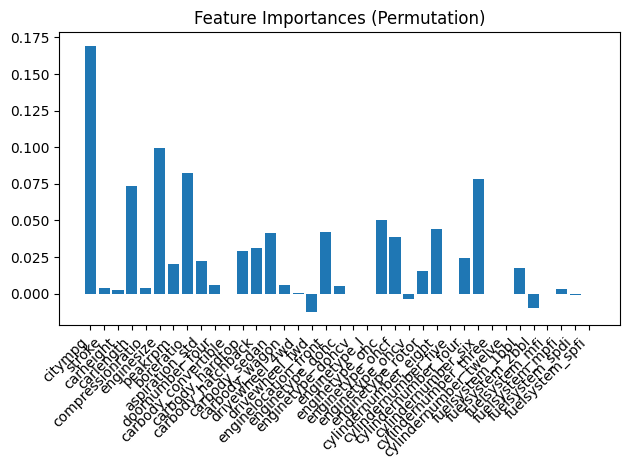

In [54]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled)))
importances = []
for i in range(X_test_scaled.shape[1]):
    X_permuted = X_test_scaled.copy()
    col = X_permuted[:, i].copy()
    np.random.shuffle(col)
    X_permuted[:, i] = col
    perm_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_permuted)))
    importances.append(perm_rmse - baseline_rmse)

feature_names = np.array(X_train.columns)
plt.bar(x=feature_names, height=importances)
plt.title("Feature Importances (Permutation)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
